In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Question 1

In [2]:
def intensity_transform(im, breakpoints):
    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    c = np.array(breakpoints)
    t1 = np.linspace(c[0,1],c[1,1], c[1,0]-c[0,0]+1).astype('uint8')
    t2 = np.linspace(c[1,1]+1,c[2,1], 1)
    t3 = np.linspace(c[2,1]+1,c[3,1], c[3,0]-c[2,0]-1).astype('uint8')
    t4 = np.linspace(c[4,1],c[3,1]+1, 1)
    t5 = np.linspace(c[4,1]+1,c[5,1], c[5,0]-c[4,0]-1).astype('uint8')
    print(len(t1),len(t2),len(t3),len(t4),len(t5))
    transform = np.concatenate((t1, t2,t3,t4), axis=0).astype('uint8')
    transform = np.concatenate((transform, t5), axis=0).astype('uint8')
    print(len(transform))
    image_transformed = cv.LUT(img, transform)
    fig, ax = plt.subplots(1,2, figsize = (10,12))
    ax[0].plot(transform)
    ax[0].set_xlabel(r'Input Intensity')
    ax[0].set_ylabel('Output Intensity')
    ax[0].set_xlim(0,255)
    ax[0].set_ylim(0,255)
    ax[0].set_aspect('equal') 
    ax[0].grid()
    ax[1].imshow(image_transformed, cmap='gray', vmin=0, vmax=255)
    ax[1].set_title('Intensity Transformed Image')
    ax[1].axis('off')
    plt.show()

51 1 99 1 104
256


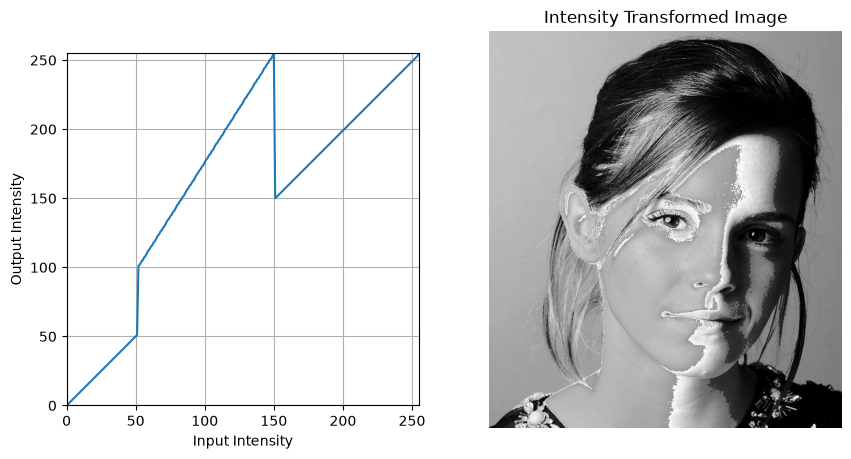

In [3]:
im = "emma.jpg"
breakpoints = [(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]
intensity_transform(im,breakpoints)

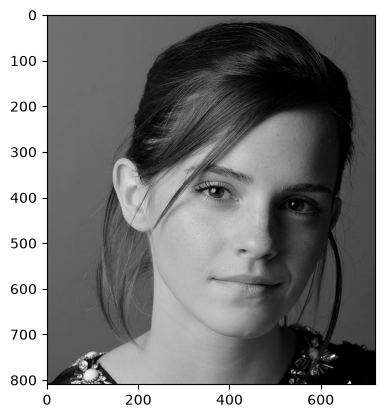

In [4]:
img = cv.imread(im, cv.IMREAD_GRAYSCALE)
fig,ax = plt.subplots()
ax.imshow(img, cmap='gray', vmin=0, vmax=255)

Question 2

GRAY

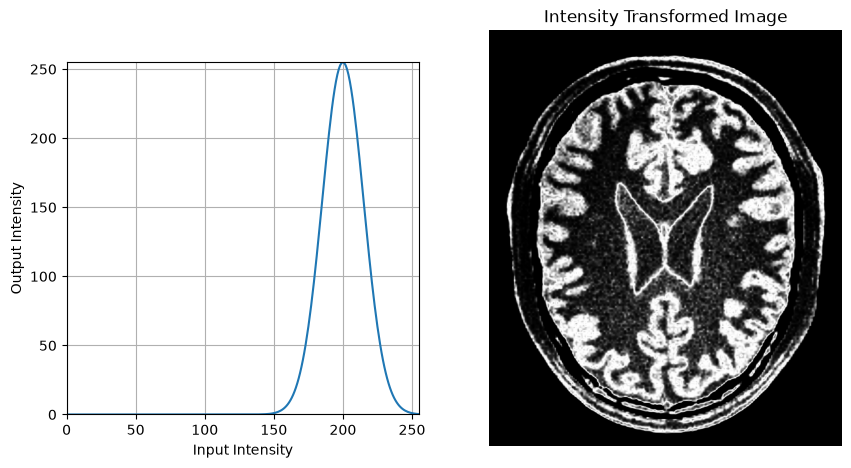

In [5]:
img = cv.imread("brain.png", cv.IMREAD_GRAYSCALE)
mu = 200
sigma = 15
x = np.linspace (0 , 255 , 256)
t = 255 * np.exp ( -(( x - mu ) **2) / (2 * sigma **2) )
t = np.clip (t , 0 , 255)
g = t[img]
fig, ax = plt.subplots(1,2, figsize = (10,12))
ax[0].plot(t)
ax[0].set_xlabel(r'Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].set_aspect('equal') 
ax[0].grid()
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Intensity Transformed Image')
ax[1].axis('off')
plt.show()

WHITE

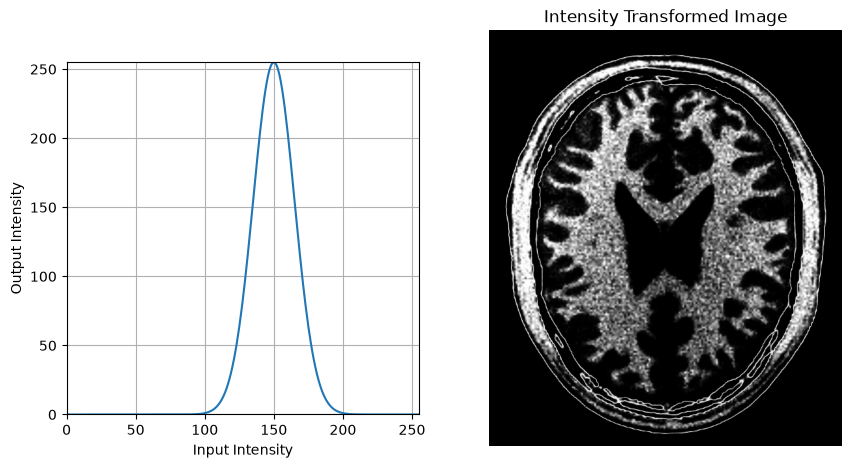

In [6]:
img = cv.imread("brain.png", cv.IMREAD_GRAYSCALE)
mu = 150
sigma = 15
x = np.linspace (0 , 255 , 256)
t = 255 * np.exp ( -(( x - mu ) **2) / (2 * sigma **2) )
t = np.clip (t , 0 , 255)
g = t[img]
fig, ax = plt.subplots(1,2, figsize = (10,12))
ax[0].plot(t)
ax[0].set_xlabel(r'Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].set_aspect('equal') 
ax[0].grid()
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Intensity Transformed Image')
ax[1].axis('off')
plt.show()

Question 3

In [7]:
im = cv.imread("gamma.png")
im_original = cv.cvtColor(im, cv.COLOR_BGR2RGB) 
im_test = cv.cvtColor(im, cv.COLOR_BGR2LAB)
assert im is not None

In [8]:
L,a,b = cv.split(im_test)
gamma = 0.75
t = np.array([(i/255.0)**(gamma)*255 for i in np.arange(0, 256)]).astype('uint8')
L_mod = cv.LUT(L, t)
im_merged = cv.merge([L_mod,a,b])
im_mod = cv.cvtColor(im_merged, cv.COLOR_LAB2RGB)

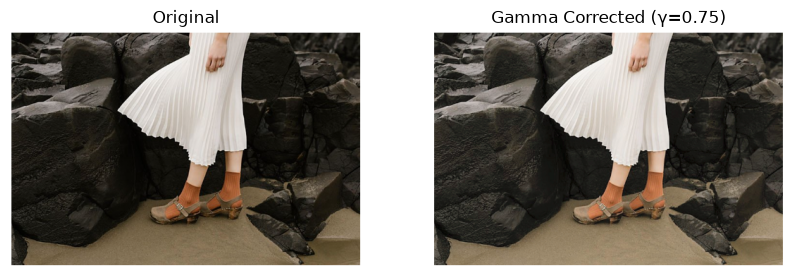

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 12))
axs[0].imshow(im_original)
axs[0].set_title('Original')
axs[0].axis('off')  
axs[1].imshow(im_mod)
axs[1].set_title(f'Gamma Corrected (γ={gamma})')
axs[1].axis('off')
plt.show()

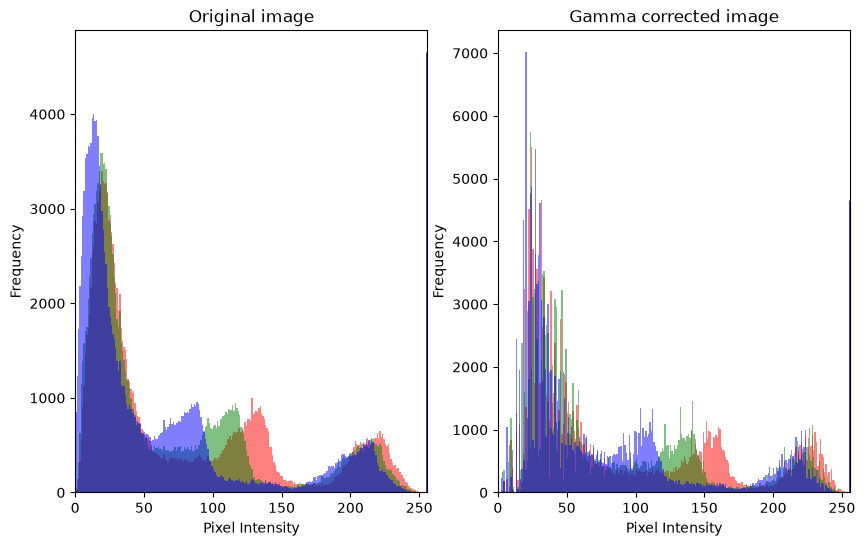

In [20]:
colors = ('r', 'g', 'b')
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
for i in range(3):
    plt.hist(im_original[:, :, i].ravel(), bins=256, range=(0, 256), color=colors[i], alpha=0.5)
plt.title('Original image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.subplot(1, 2, 2)
for i in range(3):
    plt.hist(im_mod[:, :, i].ravel(), bins=256, range=(0, 256), color=colors[i], alpha=0.5)
plt.title('Gamma corrected image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

Question 4

In [23]:
im = cv.imread('spiderman.png')
assert im is not None
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
H, S, V = cv.split(im_hsv)

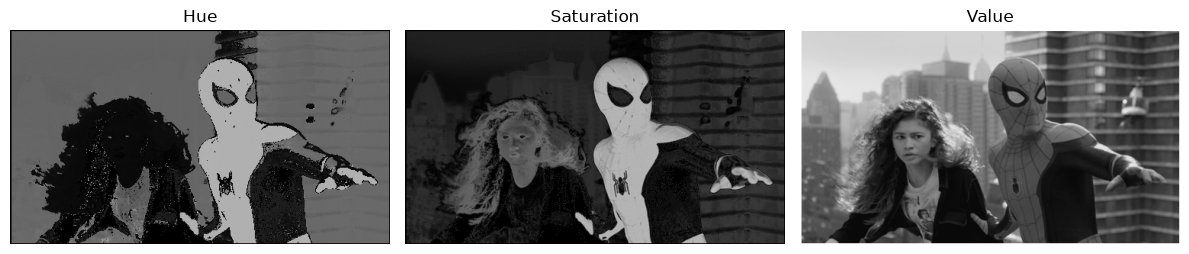

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(12, 8))
ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

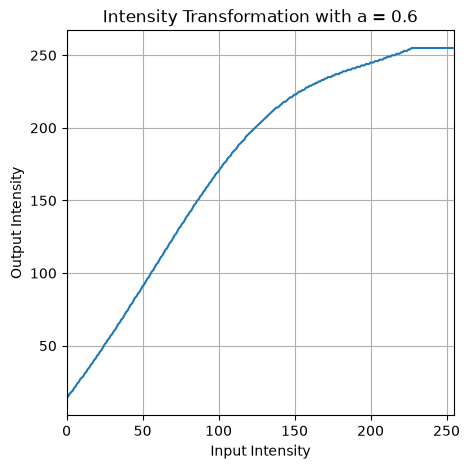

In [26]:
a = 0.6
sigma = 70.0 
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')
plt.figure(figsize=(5, 5))
plt.plot(x, f)
plt.title('Intensity Transformation with a = 0.6')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid()
plt.xlim([0, 255])
plt.xlim([0, 255])
plt.show()

In [27]:
S_mod = cv.LUT(S, f)
im_merged = cv.merge([H, S_mod, V])
im_modified = cv.cvtColor(im_merged, cv.COLOR_HSV2RGB)

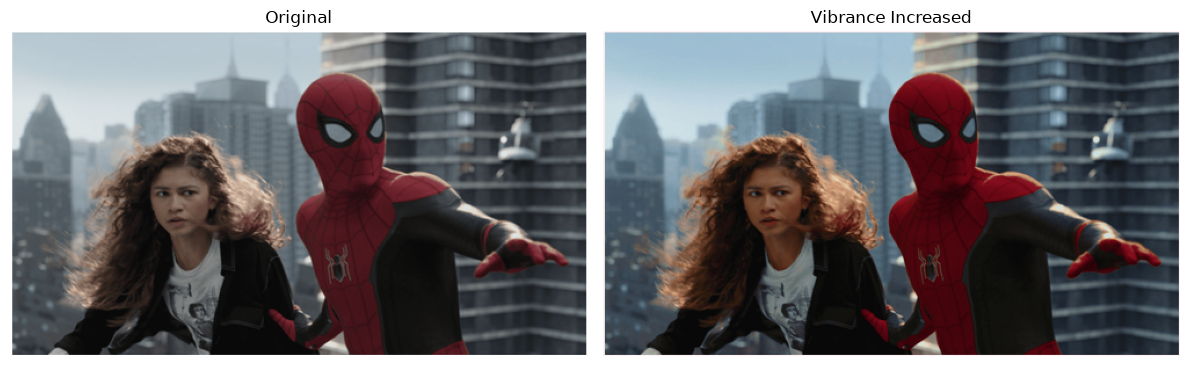

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(im_rgb)
ax[0].set_title('Original')
ax[1].imshow(im_modified)
ax[1].set_title('Vibrance Increased')
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

Question 5

(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

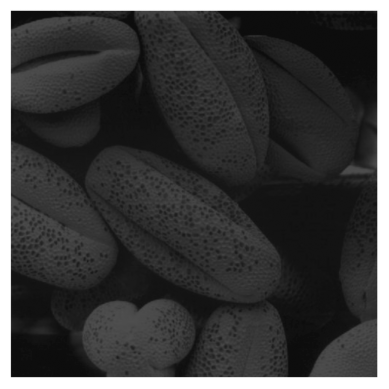

In [35]:
im = cv.imread("rocks.png", cv.IMREAD_GRAYSCALE)
fig,ax = plt.subplots()
ax.imshow(im, cmap='gray', vmin=0, vmax=255)
ax.axis("off")

In [39]:
L = 256
M,N = im.shape
hist = cv.calcHist([im],[0], None, [L],[0,L])
hist_sum = hist.cumsum()
t = np.array([(L-1)/(M*N)*hist_sum[k] for k in range(256)]).astype("uint8")
im_eq = t[im]

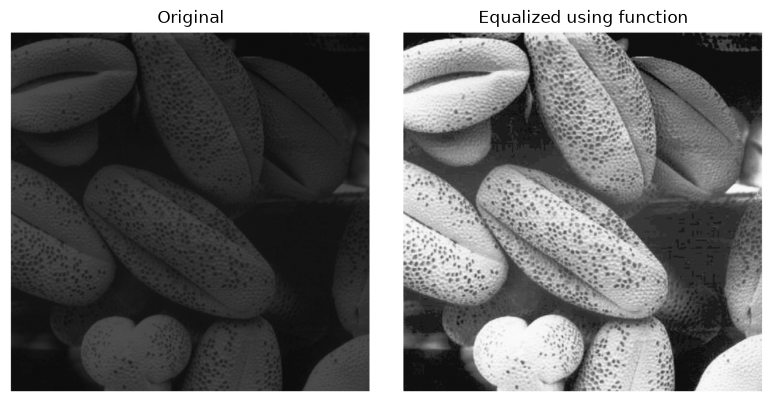

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(im_eq, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")

# Show the plot
plt.tight_layout()
plt.show()

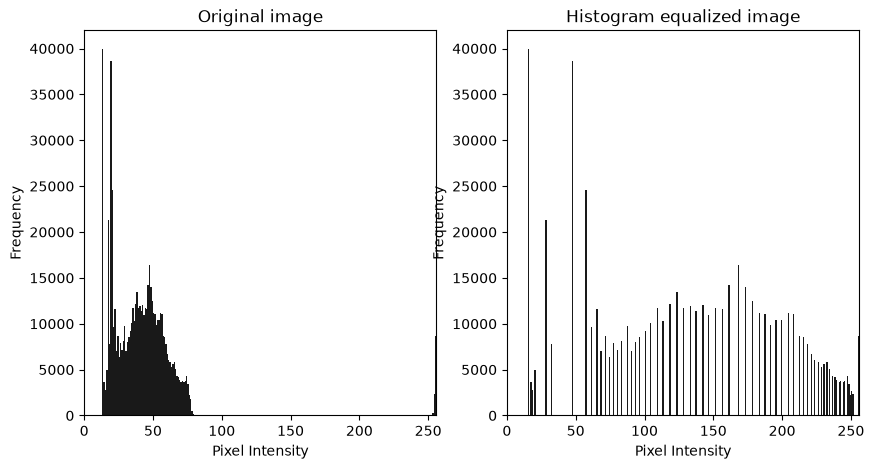

In [43]:
hist1 = cv.calcHist([im], [0], None, [256], [0, 256])
hist2 = cv.calcHist([im_eq], [0], None, [256], [0, 256])
plt.figure(figsize=(10, 5))
im_flat = im.flatten()
im_eq_flat = im_eq.flatten()
plt.subplot(1, 2, 1)
plt.hist(im_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Original image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.subplot(1, 2, 2)
plt.hist(im_eq_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Histogram equalized image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

Question 6

In [57]:
q6 = cv.imread('jennifer.png')
assert im is not None
im_hsv = cv.cvtColor(q6, cv.COLOR_BGR2HSV)
im_rgb = cv.cvtColor(q6, cv.COLOR_BGR2RGB)
H, S, V = cv.split(q6_hsv)

NameError: name 'q6_hsv' is not defined

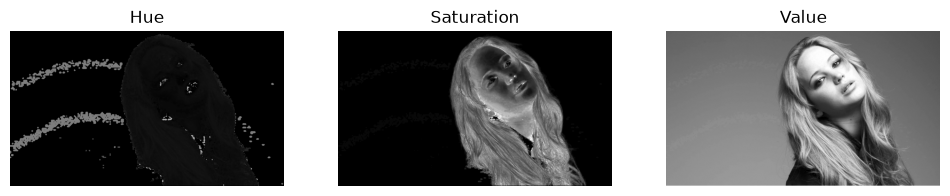

In [58]:
fig, ax = plt.subplots(1, 3, figsize=(12, 8))
ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
for a in ax:
    a.axis("off")
plt.show()

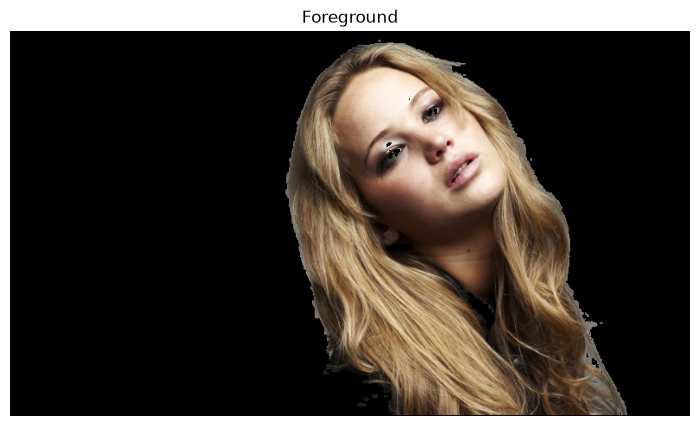

In [46]:
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)
foreground = cv.bitwise_and(q6, q6, mask=mask)
plt.figure(figsize=(10, 5))
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Foreground')
plt.axis('off')
plt.show()

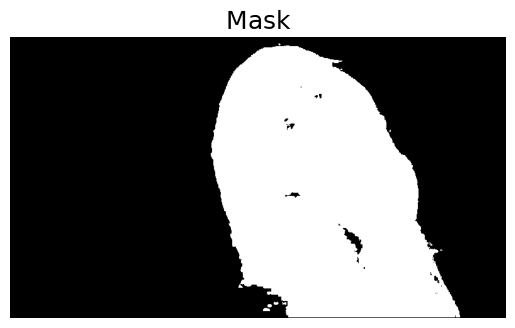

In [55]:
plt.imshow(mask, cmap='gray')
plt.title('Mask', fontsize=18)
plt.axis('off')
plt.show()

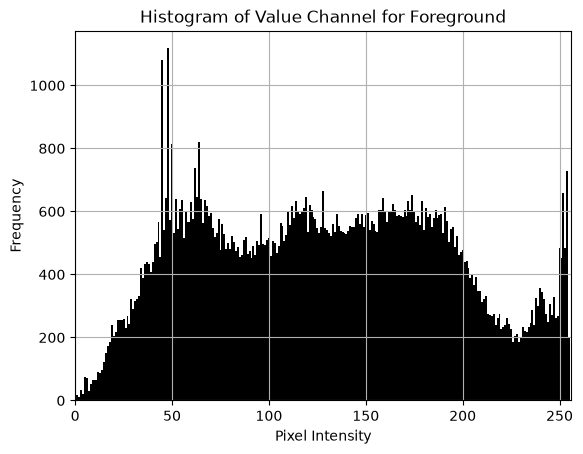

In [47]:
foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
H_fg, S_fg, V_fg = cv.split(foreground_hsv)
hist = cv.calcHist([V_fg], [0], mask, [256], [0, 256])
x_positions = np.arange(len(hist))
plt.figure()
plt.bar(x_positions, hist.flatten(), color='black', width=1)
plt.title('Histogram of Value Channel for Foreground')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

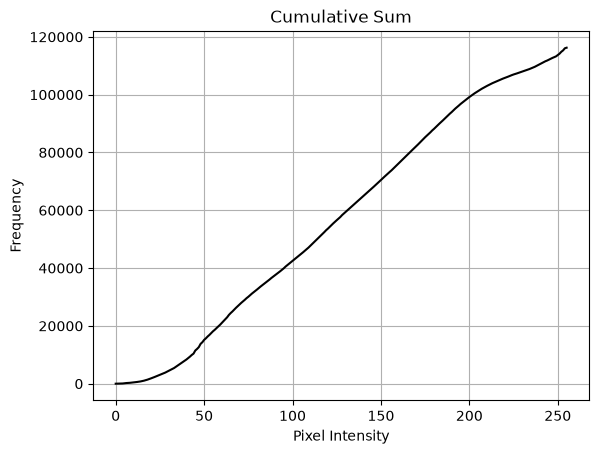

In [50]:
cdf = hist.cumsum()
plt.figure()
plt.plot(cdf, color='black')
plt.title('Cumulative Sum')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [52]:
pixels = cdf[-1]
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")
V_eq = t[V_fg]
hist = cv.calcHist([V_eq], [0], mask, [256], [0, 256])
merged = cv.merge([H_fg, S_fg, V_eq])
foreground_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)

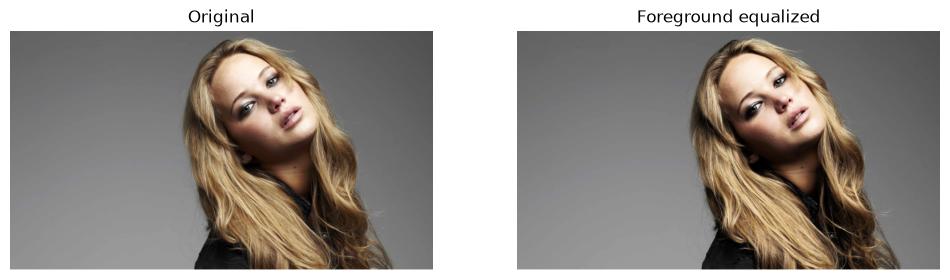

In [54]:
background = cv.bitwise_and(q6, q6, mask=cv.bitwise_not(mask))
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), foreground_modified)
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
axs[0].imshow(im_rgb)
axs[0].set_title('Original')
axs[0].axis('off') 
axs[1].imshow(result)
axs[1].set_title('Foreground equalized')
axs[1].axis('off')
plt.show()

Question 7

In [56]:
q7 = cv.imread('einstein.png', cv.IMREAD_GRAYSCALE)
assert einstein is not None